In [92]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv(override=True)
engine = create_engine(
    f"postgresql+psycopg2://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}",
    pool_pre_ping=True,     # ping the pooled conn before use; silently replace dead ones
    pool_recycle=300,       # and recycle anything older than 5 min
)
pd.read_sql("SELECT 1 AS ok", engine)

python-dotenv could not parse statement starting at line 17


,ok
0,1


Setup financials & tickers for hiring dataset

In [93]:
fin = pd.read_sql("SELECT * FROM financials_quarterly ORDER BY ticker, quarter", engine)
fin["quarter"] = pd.to_datetime(fin["quarter"])
fin["rd_intensity"] = fin["rd_spend"] / fin["revenue"]

HIRING_TICKERS = ["AMD","AVGO","CDNS","INTC","MRVL","MU","NVDA","QCOM","TXN"]
core = fin[fin["ticker"].isin(HIRING_TICKERS)].copy()
print(core.groupby("ticker").size().to_string())   # quarters per ticker

ticker
AMD     19
AVGO    20
CDNS    19
INTC    19
MRVL    20
MU      19
NVDA    20
QCOM    18
TXN     19


Hiring Snapshot completeness verificiation


In [94]:
df = pd.read_sql("""
    SELECT snapshot_date, ticker, title
    FROM hiring_signals
    WHERE snapshot_date = (SELECT MAX(snapshot_date) FROM hiring_signals)
""", engine)

assert df["snapshot_date"].nunique() == 1, "expected exactly one snapshot date"
SNAP_DATE = df["snapshot_date"].iloc[0]
print(df.shape, "|", df["ticker"].nunique(), "tickers | snapshot", SNAP_DATE)

(10859, 3) | 9 tickers | snapshot 2026-07-14


Classifier from 03_hiring_category.ipynb

    - Note : AI-flagged only means AI is within the title of the job, does not directly mean if the job is an AI job, or magnitude of relation/usage to and of AI

In [95]:
# Role/AI classifier — copied verbatim from 03_hiring_category so 20 stands alone.
# If these rules ever change, change them in both places (or factor into a module then).
import re
AI_PAT = re.compile(r"\b(ai|ml|machine learning|deep learning|neural|llm|large language model|generative|genai|computer vision|nlp|natural language|transformer|reinforcement learning)\b")

ROLE_RULES = [
    ("Product Management",        r"\b(product manager|product management|product owner|head of product|director of product)\b"),
    ("Program / Project Mgmt",    r"\b(program manager|project manager|technical program|tpm|scrum master|release manager|agile)\b"),
    ("Sales / Field / Marketing", r"\b(application engineer|applications engineer|field application|solution architect|solutions architect|solutions engineer|sales|account manager|account executive|account director|business development|customer success|field engineer|presales|marketing|developer relations|client manager|enablement)\b"),
    ("Data & Analytics",          r"\b(data scientist|data engineer|data analyst|analytics|business intelligence)\b"),
    ("Corporate / Ops / G&A",     r"\b(accountant|accounting|finance|financial|controller|human resources|hr|employee relations|recruit|talent acquisition|legal|counsel|paralegal|facilities|supply chain|supply management|procurement|sourcing|supplier management|supplier manager|buyer|purchasing|payroll|logistics|operations|cost control|business analyst|program analyst|it support|help desk|administrative|executive assistant|corporate communications)\b"),
    ("Research / Science",        r"\b(research scientist|researcher|scientist|applied scientist|principal scientist|research engineer|post-doc|postdoc|post doc)\b"),
    ("Verification & Validation", r"\b(verification|validation|formal verification|emulation)\b"),
    ("Software & Firmware",       r"\b(software|firmware|embedded|device driver|sdk|kernel|compiler|full stack|fullstack|developer|devops|site reliability)\b"),
    ("Manufacturing & Process",   r"\b(process|equipment|manufacturing|fab|hvm|yield|packaging|assembly|technician|reliability|failure analysis|test engineer|production|industrial|quality|supplier quality|mechanical|mfg|product engineer|product development|module|npi|amhs)\b"),
    ("Design (silicon/IC)",       r"\b(design|designer|analog|mixed signal|mixed-signal|rtl|layout|asic|soc|silicon|chip|dft|vlsi|circuit|standard cell|cad)\b"),
    ("Systems & Architecture",    r"\b(systems|system engineer|architect|architecture|integration|signal integrity|performance|hardware|board)\b"),
    ("Engineering (unspecified)", r"\b(engineer|engineering)\b"),
    ("Management (general)",      r"\b(manager|mgr|director|management|head of|vice president|vp|chief|supervisor)\b"),
]
ROLE_RULES = [(name, re.compile(pat)) for name, pat in ROLE_RULES]

def classify_role(title):
    t = title.lower()
    for name, pat in ROLE_RULES:
        if pat.search(t):
            return name
    return "Other / Unclassified"

df["role_bucket"] = df["title"].fillna("").apply(classify_role)
df["is_ai"]       = df["title"].fillna("").apply(lambda t: bool(AI_PAT.search(t.lower())))

print(f"Unclassified: {(df['role_bucket']=='Other / Unclassified').mean():.1%}   |   "
      f"AI-flagged: {df['is_ai'].mean():.1%} ({int(df['is_ai'].sum())} jobs)")

Unclassified: 4.1%   |   AI-flagged: 9.7% (1050 jobs)


Aggregates

In [96]:
ai = (df.groupby("ticker")["is_ai"]
        .agg(ai_jobs="sum", n_jobs="count"))
ai["ai_pct"] = (ai["ai_jobs"] / ai["n_jobs"] * 100).round(1)
ai = ai.sort_values("ai_pct", ascending=False)

mix = pd.crosstab(df["ticker"], df["role_bucket"], normalize="index").mul(100).round(1)
mix = mix[df["role_bucket"].value_counts().index]

print("AI share per ticker:")
print(ai.to_string())
print("\nRole mix (% of each ticker's postings) — buckets as rows:")
print(mix.T.to_string())

AI share per ticker:
        ai_jobs  n_jobs  ai_pct
ticker                         
NVDA        477    2553    18.7
QCOM        267    1738    15.4
AMD         127    1038    12.2
INTC         43     640     6.7
CDNS         32     598     5.4
AVGO         10     337     3.0
MU           77    2831     2.7
TXN           9     523     1.7
MRVL          8     601     1.3

Role mix (% of each ticker's postings) — buckets as rows:
ticker                      AMD  AVGO  CDNS  INTC  MRVL    MU  NVDA  QCOM   TXN
role_bucket                                                                    
Manufacturing & Process     8.7  18.7   9.5  22.7   7.8  34.7   7.5   6.4  31.4
Design (silicon/IC)        20.0  25.8  19.1  20.8  31.8  10.3  11.9  16.9  16.3
Software & Firmware        16.1  13.6  22.6   7.5   5.8   2.5  26.6  20.1   4.6
Engineering (unspecified)   5.5  10.4   7.0   8.4   7.7  19.4   8.7  19.7   7.3
Verification & Validation  14.9   5.6  11.2  11.4  22.5   4.0   9.4   7.1   6.9
Sales / 

In [97]:
# ── Financial side: collapse each ticker to ONE trailing-4-quarter (TTM) row ──
# operating_margin is stored as a fraction; rebuild quarterly operating income so
# the TTM ratios are revenue-weighted (Σ ÷ Σ), not a mean of quarterly ratios.
core = core.sort_values(["ticker", "quarter"])
last4 = core.groupby("ticker").tail(4).copy()

# completeness guard — want q=4 and zero NaNs per ticker before trusting the sums
chk = last4.groupby("ticker").agg(
    q=("quarter", "size"),
    rev_na=("revenue", lambda s: s.isna().sum()),
    rd_na=("rd_spend", lambda s: s.isna().sum()),
    om_na=("operating_margin", lambda s: s.isna().sum()),
)
print("TTM window (want q=4, all *_na=0):")
print(chk.to_string())
print(f"\nwindow spans {last4['quarter'].min().date()} … {last4['quarter'].max().date()} "
      f"(fiscal calendars differ, so per-ticker windows vary slightly)\n")

last4["op_income"] = last4["operating_margin"] * last4["revenue"]
g = last4.groupby("ticker")
# match revenue to R&D availability → numerator and denominator span the SAME quarters
rev_rd = last4.loc[last4["rd_spend"].notna()].groupby("ticker")["revenue"].sum()
fin_ttm = pd.DataFrame({
    "rd_intensity":     g["rd_spend"].sum() / rev_rd,                    # both over same quarters
    "rd_qtrs":          g["rd_spend"].apply(lambda s: s.notna().sum()),  # quarters backing it (4 = full)
    "operating_margin": g["op_income"].sum() / g["revenue"].sum(),       # fraction; ×100 for %
})

# ── Merge: hiring features + TTM financial profile, one row per ticker ──
SEGMENT = {"NVDA":"Fabless","AMD":"Fabless","QCOM":"Fabless","AVGO":"Fabless","MRVL":"Fabless",
           "INTC":"IDM","MU":"IDM","TXN":"IDM","CDNS":"EDA"}

signals = (ai[["n_jobs", "ai_pct"]]
             .join(mix)          # role-mix % columns
             .join(fin_ttm))     # rd_intensity + operating_margin (TTM, fractions)
signals.insert(0, "segment", signals.index.map(SEGMENT))

print(signals.shape, "→ 9 tickers ×", signals.shape[1], "cols")
signals.round(3)

TTM window (want q=4, all *_na=0):
        q  rev_na  rd_na  om_na
ticker                         
AMD     4       0      0      0
AVGO    4       0      0      0
CDNS    4       0      0      0
INTC    4       0      0      0
MRVL    4       0      0      0
MU      4       0      0      0
NVDA    4       0      0      0
QCOM    4       0      0      0
TXN     4       0      0      0

window spans 2025-06-28 … 2026-05-28 (fiscal calendars differ, so per-ticker windows vary slightly)

(9, 20) → 9 tickers × 20 cols


,segment,n_jobs,ai_pct,Manufacturing & Process,Design (silicon/IC),Software & Firmware,Engineering (unspecified),Verification & Validation,Sales / Field / Marketing,Systems & Architecture,Corporate / Ops / G&A,Other / Unclassified,Program / Project Mgmt,Management (general),Product Management,Research / Science,Data & Analytics,rd_intensity,rd_qtrs,operating_margin
ticker,,,,,,,,,,,,,,,,,,,,
NVDA,Fabless,2553,18.7,7.5,11.9,26.6,8.7,9.4,12.9,8.7,2.1,1.8,3.4,2.0,1.7,2.9,0.4,0.082,4,0.640
QCOM,Fabless,1738,15.4,6.4,16.9,20.1,19.7,7.1,4.7,9.9,3.6,4.5,1.8,1.3,2.1,1.1,0.9,0.214,4,0.255
AMD,Fabless,1038,12.2,8.7,20.0,16.1,5.5,14.9,6.6,9.9,4.9,3.2,5.3,2.0,1.3,1.0,0.7,0.234,4,0.117
INTC,IDM,640,6.7,22.7,20.8,7.5,8.4,11.4,7.0,4.7,8.1,4.2,2.2,1.6,0.3,0.5,0.6,0.251,4,-0.094
CDNS,EDA,598,5.4,9.5,19.1,22.6,7.0,11.2,16.7,5.4,2.8,3.8,1.0,0.5,0.3,0.0,0.0,0.332,4,0.283
AVGO,Fabless,337,3.0,18.7,25.8,13.6,10.4,5.6,7.7,6.5,2.7,3.3,1.5,2.1,1.8,0.0,0.3,0.159,4,0.434
MU,IDM,2831,2.7,34.7,10.3,2.5,19.4,4.0,2.5,2.9,10.0,6.1,1.7,2.9,0.7,0.0,2.4,0.053,4,0.656
TXN,IDM,523,1.7,31.4,16.3,4.6,7.3,6.9,13.6,4.0,7.1,6.9,0.0,1.3,0.0,0.2,0.6,0.138,4,0.265
MRVL,Fabless,601,1.3,7.8,31.8,5.8,7.7,22.5,5.5,5.2,4.0,3.2,3.0,3.0,0.5,0.2,0.0,0.255,4,0.160


In [98]:
from sqlalchemy import text
q4_rd = 1_768_772_000 - 1_304_190_000   # FY2025 annual − 9mo YTD = 464,582,000
with engine.begin() as conn:
    n = conn.execute(text("""
        UPDATE financials_quarterly SET rd_spend = :v
        WHERE ticker='CDNS' AND quarter='2025-12-31' AND rd_spend IS NULL
    """), {"v": q4_rd}).rowcount
print(f"updated {n} row(s) — CDNS Q4 2025 R&D = {q4_rd/1e9:.3f}B")

updated 0 row(s) — CDNS Q4 2025 R&D = 0.465B


Q4 was recorded as NULL for Cadence

    - Q4 R&D was tagged under a different XBRL concept in EGDAR, ran through Claude to debug and made a quick one-row idempotent Update to patch.


In [99]:
hire = ["ai_pct", "Software & Firmware"]
fin_cols = ["rd_intensity", "operating_margin"]

# Spearman (rank) is the primary read here: n=9 with real extremes (NVDA, MU),
# and the question is "do they move together in rank," not "linearly."
sp = signals[hire + fin_cols].corr(method="spearman").loc[hire, fin_cols]
pe = signals[hire + fin_cols].corr(method="pearson").loc[hire, fin_cols]

print("Spearman (rank):");  print(sp.round(2).to_string())
print("\nPearson (linear):"); print(pe.round(2).to_string())
print(f"\nai_pct ~ software/firmware: "
      f"spearman {signals['ai_pct'].corr(signals['Software & Firmware'], method='spearman'):.2f} | "
      f"pearson {signals['ai_pct'].corr(signals['Software & Firmware'], method='pearson'):.2f}")
print("n = 9 — directional, not significance-grade.")

Spearman (rank):
                     rd_intensity  operating_margin
ai_pct                      -0.08             -0.05
Software & Firmware          0.25              0.03

Pearson (linear):
                     rd_intensity  operating_margin
ai_pct                       -0.1              0.14
Software & Firmware           0.2              0.20

ai_pct ~ software/firmware: spearman 0.80 | pearson 0.78
n = 9 — directional, not significance-grade.


Analysis (AT TIME OF ANALYSIS, exact numbers might slightly differ as database is updated daily but main insights should still hold relatively true)

    - Looking into AI-PCT (percentages of "AI" in job titles) and comparing it to % of Software/Firmware roles and operating margin & R&D Intensity (R&D Spend/Revenue). I found that there is no concrete correlation between operating margin and the other 2 but that there was a correlation between AI-PCT and % of Software/Firmware roles.
        - Remember that Correlation does NOT = Causation but this could hint at more software/firmware dominated companies being more invested within utilizing AI and hiring jobs with AI integration to be able to improve their software/firmware products.
    - Conducted a Spearman rank-correlation analysis to verify the eye-test I performed and my eye-test held true as there was a a relatively strong correlation between AI PCT and software/firmware % of jobs through both spearman and pearson at 0.8 and 0.78 respectively. In regards to the financials and their correlations to AI PCT and Software/Firmware % of jobs, there is no strong correlations given the numbers being close to 0.

Spearman = Correlation pertaining to how close two variabes move together in the same order
Pearson = Correlation pertaining to how much two variables move together in a straight line


In [100]:
role_cols = list(mix.columns)          # the 14 role buckets, from Cell 4

seg_n = signals["segment"].value_counts()
print("segment sizes:", seg_n.to_dict(), "— EDA is n=1 (CDNS alone)\n")

# mean role mix per segment
seg_mix = signals.groupby("segment")[role_cols].mean().round(1)

# which buckets separate segments most: spread = max - min across the segment means
spread = (seg_mix.max() - seg_mix.min()).sort_values(ascending=False)

print("Mean role mix by segment (%) — columns ordered by between-segment spread:")
print(seg_mix[spread.index].T.to_string())
print("\nMost segment-separating buckets (max−min of segment means, pts):")
print(spread.round(1).to_string())

segment sizes: {'Fabless': 5, 'IDM': 3, 'EDA': 1} — EDA is n=1 (CDNS alone)

Mean role mix by segment (%) — columns ordered by between-segment spread:
segment                     EDA  Fabless   IDM
Manufacturing & Process     9.5      9.8  29.6
Software & Firmware        22.6     16.4   4.9
Sales / Field / Marketing  16.7      7.5   7.7
Corporate / Ops / G&A       2.8      3.5   8.4
Design (silicon/IC)        19.1     21.3  15.8
Engineering (unspecified)   7.0     10.4  11.7
Verification & Validation  11.2     11.9   7.4
Systems & Architecture      5.4      8.0   3.9
Other / Unclassified        3.8      3.2   5.7
Program / Project Mgmt      1.0      3.0   1.3
Management (general)        0.5      2.1   1.9
Product Management          0.3      1.5   0.3
Data & Analytics            0.0      0.5   1.2
Research / Science          0.0      1.0   0.2

Most segment-separating buckets (max−min of segment means, pts):
Manufacturing & Process      20.1
Software & Firmware          17.7
Sales / Fi

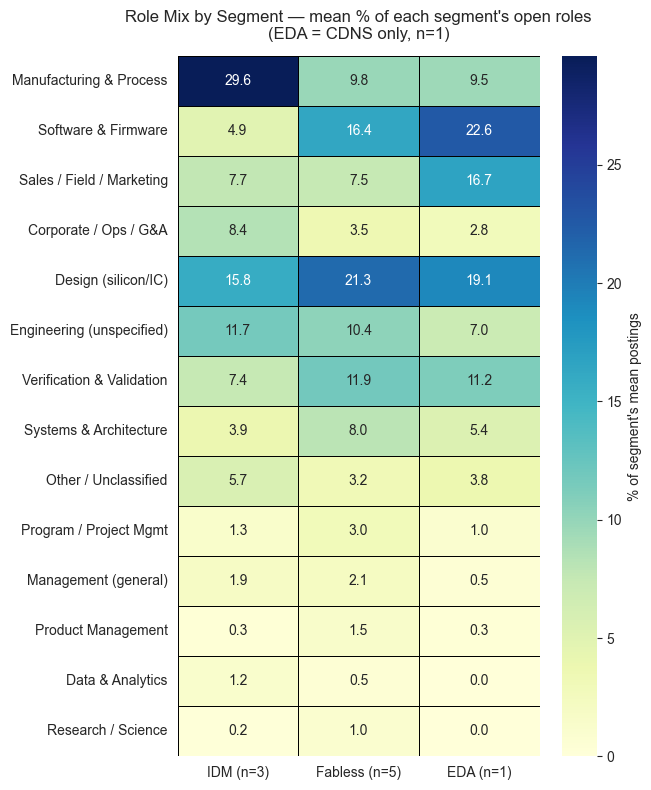

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# self-contained: role buckets = signals columns minus the id/financial ones
non_role = ["segment", "n_jobs", "ai_pct", "rd_intensity", "operating_margin", "rd_qtrs"]
role_cols = [c for c in signals.columns if c not in non_role]

seg_mix = signals.groupby("segment")[role_cols].mean().round(1)
spread  = (seg_mix.max() - seg_mix.min()).sort_values(ascending=False)

seg_order = ["IDM", "Fabless", "EDA"]                 # manufacturing pole -> software pole
seg_mix = seg_mix.loc[seg_order, spread.index]        # rows=segments (gradient), cols=buckets (by spread)
seg_mix.index = [f"{s} (n={(signals['segment'] == s).sum()})" for s in seg_order]

plt.figure(figsize=(6.5, 8))
sns.heatmap(
    seg_mix.T,                    # buckets as rows (by spread), segments as columns
    annot=True, fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.7, linecolor='black',
    cbar_kws={'label': "% of segment's mean postings"},
)
plt.title("Role Mix by Segment — mean % of each segment's open roles\n"
          "(EDA = CDNS only, n=1)", fontsize=12, pad=12)
plt.xlabel(""); plt.ylabel("")
plt.tight_layout()
plt.savefig("role_mix_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()

Analysis

    - Looking into the cross-segment heatmap, we find that...
        - For IDM companies, Manufacturing & Process jobs % is evidently a much higher share which is predictable given IDM companies produce the chips that they also design so manufacturing has a higher emphasis than a Fabless or EDA company would.
        - The opposite pattern holds true for Software/Firmware jobs % as Fabless companies have a higher focus over IDM on the desinging of chips and/or innovating softwares/firmwares that make designing improved chips possible. EDA falls deeper onto this end exceeding Fabless.

        - Financial Ratios dont bring much correlations/possible insights pertaining to % of job share per category but business model is a reliable predictor. 
            - Although this insight is not too profound as it would be what is expected given the focus of these different segments.


In [102]:
signals[["segment", "ai_pct", "n_jobs"]].sort_values("ai_pct", ascending=False).round(1)

,segment,ai_pct,n_jobs
ticker,,,
NVDA,Fabless,18.7,2553
QCOM,Fabless,15.4,1738
AMD,Fabless,12.2,1038
INTC,IDM,6.7,640
CDNS,EDA,5.4,598
AVGO,Fabless,3.0,337
MU,IDM,2.7,2831
TXN,IDM,1.7,523
MRVL,Fabless,1.3,601


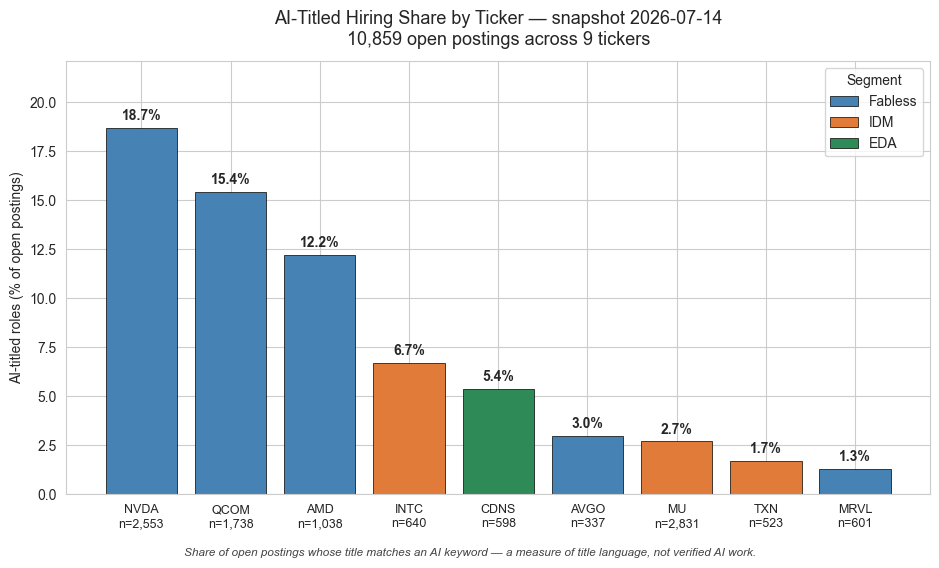

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

PALETTE = {"Fabless": "steelblue", "IDM": "#e07b39", "EDA": "seagreen"}
d = signals[["segment", "ai_pct", "n_jobs"]].sort_values("ai_pct", ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars = ax.bar(range(len(d)), d["ai_pct"],
              color=[PALETTE[s] for s in d["segment"]], edgecolor="black", linewidth=0.5)

for b, pct in zip(bars, d["ai_pct"]):                       # value labels above bars
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.25,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ticker + posting base on the axis — the denominator matters (MU posts most, leans AI least)
ax.set_xticks(range(len(d)))
ax.set_xticklabels([f"{t}\nn={n:,}" for t, n in zip(d.index, d["n_jobs"])], fontsize=9)

handles = [plt.Rectangle((0, 0), 1, 1, color=c, ec="black", lw=0.5) for c in PALETTE.values()]
ax.legend(handles, PALETTE.keys(), title="Segment", loc="upper right", frameon=True)

ax.set_ylabel("AI-titled roles (% of open postings)")
ax.set_ylim(0, d["ai_pct"].max() * 1.18)
ax.set_title(f"AI-Titled Hiring Share by Ticker — snapshot {SNAP_DATE}\n"
             f"{d['n_jobs'].sum():,} open postings across 9 tickers",
             fontsize=13, pad=12)

fig.text(0.5, -0.02,
         "Share of open postings whose title matches an AI keyword — a measure of title language, not verified AI work.",
         ha="center", fontsize=8.5, style="italic", color="#444")

plt.tight_layout()
plt.savefig("ai_pct_by_ticker.png", dpi=150, bbox_inches="tight")
plt.show()

Analysis

    - Fabless covers top 3, but AVGO middle of the pack and MRVL being at the end could hint similar to previous findings that it is more dependent on what the company actually produces specifically rather than the semiconductor segment that they are in

    - NVDA being highest given they have been the biggest company driving force behind the AI boom with their focus on GPU's to aid in the acceleration of training and producing cutting-edge LLMS

    - MRVL at lowest, a company that differentiates through their focus on networking/data infrastructure through their chip/silicon solutions.
        - Note however that AI_pct and % of jobs being software/firmware have a relatively strong correlation and with MRVL being one of the lower %'s of software/firmware jobs, this is something that makes sense